In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
#from sklearn.metrics import recall_score
from sklearn.metrics import precision_recall_fscore_support

from sklearn.metrics import roc_curve, auc , confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split


from keras.models import load_model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import RMSprop


from dataset_preparation import awgn, LoadDataset, ChannelIndSpectrogram
from deep_learning_models import TripletNet, identity_loss

import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  Conv1D, MaxPooling1D, Flatten, Dense
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


2024-09-06 10:57:07.322076: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-09-06 10:57:07.325855: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-09-06 10:57:07.365886: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-09-06 10:57:11.282283: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
def index_containing_substring(the_list, substring):
    try:
        return [s for i, s in enumerate(the_list) if substring in s][0]
    except IndexError:
        return False

In [4]:
# SPECIFIC MODULES INSTALLED MANUALLY
#%pip install keras
#%pip install tensorflow
#%pip install gdrive
#%pip install matplotlib


!unzip -q /workspaces/work/Cropped_data-20240527T214451Z-001.zip

import os.path


data_path = "/workspaces/work/Dataset/Cropped_data"
devices = os.listdir(data_path)
target_dir ="/workspaces/work/Dataset/Cropped_data/Device_1/Cihaz_1"
#"/workspaces/work/Cropped_data/Device_1/Cihaz_1"
crop_len = float('inf')

def extract_IQ_samples_from_txt_file(path_to_txt, crop_len):

    I_samples = []
    Q_samples = []

    files = os.listdir(target_dir)
    Real = [file for file in files if 'I' in file]
    Imaginary = [file for file in files if 'Q' in file]

    for file in Real:
        file_number = file.split('.')[0][1:]
        I_path_temp = index_containing_substring(Real, file_number)
        Q_temp_path = index_containing_substring(Imaginary, file_number)
        if Q_temp_path != False:
            I_path_temp = os.path.join(target_dir, I_path_temp)
            Q_temp_path = os.path.join(target_dir, Q_temp_path)
        
            I_sample = np.loadtxt(I_path_temp)
            Q_sample = np.loadtxt(Q_temp_path)

            I_len = len(I_sample)
            Q_len = len(Q_sample)

            if I_len < crop_len:
                crop_len = I_len
            if Q_len < crop_len:
                crop_len = Q_len
                
            I_samples.append(I_sample)
            Q_samples.append(Q_sample)

    return I_samples, Q_samples, crop_len


unzip:  cannot find or open /workspaces/work/Cropped_data-20240527T214451Z-001.zip, /workspaces/work/Cropped_data-20240527T214451Z-001.zip.zip or /workspaces/work/Cropped_data-20240527T214451Z-001.zip.ZIP.


In [5]:
device1_path = "/workspaces/work/Dataset/Cropped_data/Device_1/Cihaz_1"
device2_path = "/workspaces/work/Dataset/Cropped_data/Device_2/Cihaz_2"
device3_path = "/workspaces/work/Dataset/Cropped_data/Device_2/Cihaz_3"
device4_path = "/workspaces/work/Dataset/Cropped_data/Device_2/Cihaz_4"

I_samples_1, Q_samples_1, crop_len1 = extract_IQ_samples_from_txt_file(device1_path, crop_len)
I_samples_2, Q_samples_2, crop_len2 = extract_IQ_samples_from_txt_file(device2_path, crop_len1)
I_samples_3, Q_samples_3, crop_len3 = extract_IQ_samples_from_txt_file(device3_path, crop_len2)
I_samples_4, Q_samples_4, crop_len4 = extract_IQ_samples_from_txt_file(device4_path, crop_len3)

In [6]:
assert(len(I_samples_1) == len(Q_samples_1)), "lengths not equal for device 1"
assert(len(I_samples_2) == len(Q_samples_2)), "lengths not equal for device 2"
assert(len(I_samples_3) == len(Q_samples_3)), "lengths not equal for device 3"
assert(len(I_samples_4) == len(Q_samples_4)), "lengths not equal for device 4"

In [7]:
crop_len = 3000
#crop_len = crop_len4
samples_from_each_device = 843
I_samples_1, Q_samples_1 = [I_samples_1[i][:crop_len] for i in range(len(I_samples_1))], [Q_samples_1[i][:crop_len] for i in range(len(Q_samples_1))]
I_samples_2, Q_samples_2 = [I_samples_2[i][:crop_len] for i in range(len(I_samples_2))], [Q_samples_2[i][:crop_len] for i in range(len(Q_samples_2))]
I_samples_3, Q_samples_3 = [I_samples_3[i][:crop_len] for i in range(len(I_samples_3))], [Q_samples_3[i][:crop_len] for i in range(len(Q_samples_3))]
I_samples_4, Q_samples_4 = [I_samples_4[i][:crop_len] for i in range(len(I_samples_4))], [Q_samples_4[i][:crop_len] for i in range(len(Q_samples_4))]

In [9]:
crop_len4

38717

In [8]:
samples_from_each_device = 843

In [8]:
assert(len(I_samples_1) == len(Q_samples_1) == len(I_samples_2) == len(Q_samples_2) == len(I_samples_3) == len(Q_samples_3) == len(I_samples_4) == len(Q_samples_4)), "lengths not equal for all device 1"
I_samples_1, Q_samples_1 = np.array(I_samples_1), np.array(Q_samples_1)
I_samples_2, Q_samples_2 = np.array(I_samples_2), np.array(Q_samples_2)
I_samples_3, Q_samples_3 = np.array(I_samples_3), np.array(Q_samples_3)
I_samples_4, Q_samples_4 = np.array(I_samples_4), np.array(Q_samples_4)


In [12]:
I_samples_1.shape

(843, 10000)

In [9]:
samples_from_each_device = I_samples_1.shape[0]
real_part = np.vstack((I_samples_1, I_samples_2, I_samples_3, I_samples_4))
imaginary_part = np.vstack((Q_samples_1, Q_samples_2, Q_samples_3, Q_samples_4))


In [10]:
labels1 = np.array([0 for i in range(samples_from_each_device)]).reshape(samples_from_each_device, 1)
labels2 = np.array([1 for i in range(samples_from_each_device)]).reshape(samples_from_each_device, 1)
labels3 = np.array([2 for i in range(samples_from_each_device)]).reshape(samples_from_each_device, 1)
labels4 = np.array([3 for i in range(samples_from_each_device)]).reshape(samples_from_each_device, 1)
labels = np.vstack((labels1, labels2, labels3, labels4))
print(labels.shape, real_part.shape)

(3372, 1) (3372, 3000)


In [219]:
print(imaginary_part[0])

[-3.100e-05 -4.300e-05  2.100e-05 ... -8.180e-03 -5.035e-03  4.280e-04]


In [12]:
data = real_part + 1j * imaginary_part

In [16]:
print(data.shape)

(3372, 10000)


In [13]:
snr_range = np.arange(2,10)

data = awgn(data, snr_range)

In [14]:
import numpy as np

def apply_random_shift(data, max_shift):
    shift = np.random.randint(-max_shift, max_shift + 1)
    return np.roll(data, shift, axis=1)

def apply_random_noise(data, noise_level):
    noise = np.random.normal(scale=noise_level, size=data.shape)
    return data + noise

# Example usage
max_shift = 10
noise_level = 0.1

# Apply random shift and noise to a single sample
augmented_sample = apply_random_shift(data, max_shift)



In [15]:
data=augmented_sample

In [19]:
data.shape

(3372, 30000)

In [16]:
import numpy as np

def calculate_snr(data):
    """
    Calculate the Signal-to-Noise Ratio (SNR) for complex-valued data.
    
    Args:
    - data (np.ndarray): Complex-valued signal data.
    
    Returns:
    - snr_db (float): Signal-to-Noise Ratio in decibels (dB).
    """
    # Compute the magnitude of the data
    magnitude = np.abs(data)
    
    # Compute signal power (mean magnitude squared)
    signal_power = np.mean(magnitude**2)
    
    # Compute noise power (mean squared deviation from signal mean)
    noise_power = np.mean((magnitude - np.mean(magnitude))**2)
    
    # Calculate SNR
    snr = signal_power / noise_power
    snr_db = 10 * np.log10(snr)
    
    return snr_db

# Example data
data = data

# Calculate and print SNR
snr_db = calculate_snr(data)
print(f"SNR: {snr_db:.2f} dB")


SNR: 9.21 dB


In [22]:
data.shape[0]

3372

Shape of synchronized data: (3372, 3000)
Shape of compensated data: (3372, 3000)


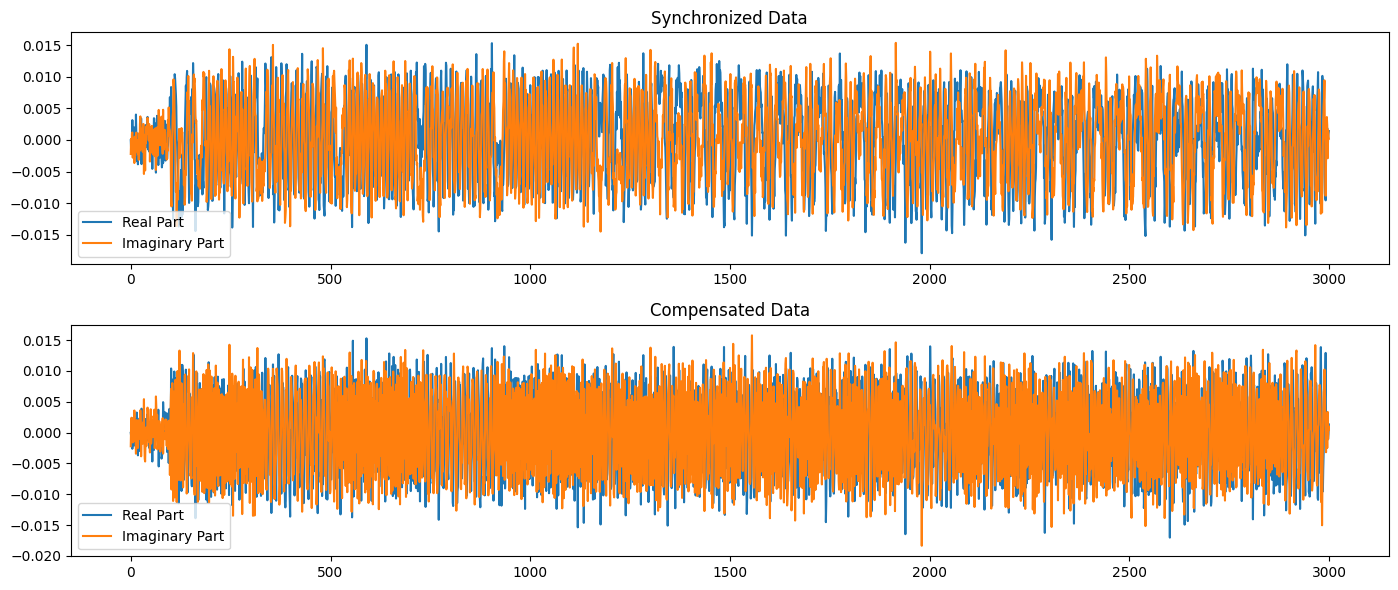

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks

# Example complex-valued data (replace with your actual data)
data_real = data

# Sample parameters
n_samples, n_features = data_real.shape

# 1. Energy Level Synchronization
def synchronize_start(data):
    # Compute energy of each segment
    energy = np.sum(np.abs(data)**2, axis=1)
    
    # Find peaks in energy (assuming peaks correspond to start of the signal)
    peaks, _ = find_peaks(energy, height=np.max(energy) * 0.5)  # Threshold can be adjusted
    
    if len(peaks) > 0:
        # Take the first peak as the start index
        start_index = peaks[0]
    else:
        start_index = 0  # No peaks found, use beginning
    
    return start_index

# Extract the relevant portion of the data, ensuring the shape remains unchanged
def extract_synchronized_data(data, start_index):
    if start_index < 0:
        start_index = 0
    
    # Ensure we do not go out of bounds by adjusting start_index
    if start_index >= data.shape[0]:
        start_index = data.shape[0] - 1

    # Pad the data at the beginning if necessary
    if start_index > 0:
        padded_data = np.pad(data, ((start_index, 0), (0, 0)), mode='constant')
        return padded_data[start_index:start_index + data.shape[0], :]
    else:
        return data

# Extract the relevant portion of the data
start_index = synchronize_start(data_real)
data_synchronized = extract_synchronized_data(data_real, start_index)

# 2. Apply Frequency Synchronization
def estimate_frequency_offset(data, sample_rate):
    """Estimate the frequency offset using FFT."""
    # Assuming data is 2D, apply FFT to each row
    n = data.shape[1]
    freq = fftfreq(n, d=1/sample_rate)
    
    # Find the peak frequencies for each segment
    offsets = []
    for segment in data:
        fft_data = fft(segment)
        abs_fft = np.abs(fft_data)
        # Find the indices of the two largest peaks
        peak_indices = np.argsort(abs_fft)[-2:]
        if len(peak_indices) < 2:
            continue
        peak_freqs = freq[peak_indices]
        offset_freq = np.mean(np.diff(np.sort(peak_freqs)))  # Average difference of sorted peak frequencies
        offsets.append(offset_freq)
    
    if len(offsets) > 0:
        return np.mean(offsets)  # Average offset across segments
    return 0  # Default if no offset is found

def compensate_frequency_offset(data, offset_freq, sample_rate):
    """Compensate for the carrier frequency offset."""
    n_samples = data.shape[1]
    t = np.arange(n_samples) / sample_rate
    compensation = np.exp(-1j * 2 * np.pi * offset_freq * t)
    return data * compensation

# Example parameters
sample_rate = 10000  # Example value in Hz
offset_freq = estimate_frequency_offset(data_synchronized, sample_rate)

# Apply the frequency compensation
data_compensated = compensate_frequency_offset(data_synchronized, offset_freq, sample_rate)

# Check the shape of the synchronized and compensated data
print(f'Shape of synchronized data: {data_synchronized.shape}')
print(f'Shape of compensated data: {data_compensated.shape}')

# Visualize a portion of the data before and after compensation
plt.figure(figsize=(14, 6))

# Original Data Visualization (before compensation)
plt.subplot(2, 1, 1)
plt.plot(np.real(data_synchronized[0, :]), label='Real Part')
plt.plot(np.imag(data_synchronized[0, :]), label='Imaginary Part')
plt.title('Synchronized Data')
plt.legend()

# Compensated Data Visualization
plt.subplot(2, 1, 2)
plt.plot(np.real(data_compensated[0, :]), label='Real Part')
plt.plot(np.imag(data_compensated[0, :]), label='Imaginary Part')
plt.title('Compensated Data')
plt.legend()

plt.tight_layout()
plt.show()


In [18]:
data=data_compensated

In [19]:
def normalize_data(data):
    rms = np.sqrt(np.mean(np.abs(data)**2))
    return data / rms
normalised_data = normalize_data(data)

In [20]:
labels

array([[0],
       [0],
       [0],
       ...,
       [3],
       [3],
       [3]])

In [26]:

labels.shape

(3372, 1)

In [49]:
normalised_data.shape

(3372, 3000)

In [27]:
normalised_data


array([[-0.02595646-0.0977125j ,  0.02661681+0.35302537j,
        -0.82540576+0.21532347j, ...,  0.62911002+0.03371304j,
         0.10751818-0.16329935j,  0.12252884-0.07446752j],
       [-0.58199645-0.88499857j, -0.33588214+0.1905087j ,
         0.55538485+0.76042137j, ..., -0.53368573-0.53882241j,
        -0.16112474+1.00710431j,  0.09328334+1.36737134j],
       [-0.98674797+0.71295934j,  0.26365257+0.83983955j,
         0.34287194-0.0629499j , ..., -0.10978735+0.63617219j,
         1.02564956+0.30393019j,  1.33799611-0.19177799j],
       ...,
       [ 0.08055942+0.27981288j, -0.29892146-0.04050039j,
        -0.19473721-0.42271462j, ...,  0.02195619-0.13997627j,
         0.07446057+0.21470989j, -0.00692798-0.03829736j],
       [ 0.02939644+1.04535948j,  1.03687119+0.71594669j,
         0.84673052-0.90041482j, ..., -0.0562579 +1.40815746j,
         1.10917185+0.70956476j,  0.37976766-0.67282795j],
       [ 0.21140184+0.46900908j,  0.33760504-0.23741278j,
         0.22636688-0.76205575

In [28]:
data=normalised_data

In [29]:
data.shape

(3372, 10000)

In [21]:
import numpy as np
import joblib
import matplotlib.pyplot as plt
from scipy.signal import stft
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Assuming X_train_pca has shape (3372, 1985)
n_samples = data.shape[0]
n_timesteps = 1500  # Define based on the number of channels
n_channels = 2    # Define based on your data

# Truncate or adjust if necessary to ensure compatibility
if n_timesteps * n_channels != 10000:
    data= data[:, :n_timesteps * n_channels]

# Reshape to (samples, timesteps, channels)
data_real = data.reshape(n_samples, n_timesteps, n_channels)

# Function to compute channel-independent spectrograms using STFT
def compute_spectrogram(data, nperseg=128, noverlap=64):
    spectrograms = []
    for sample in data:
        sample_spectrograms = []
        for channel in range(sample.shape[-1]):  # Iterate over channels
            f, t, Zxx = stft(sample[:, channel], nperseg=nperseg, noverlap=noverlap)
            sample_spectrograms.append(np.abs(Zxx))
        # Stack all channel spectrograms along the last axis
        spectrograms.append(np.stack(sample_spectrograms, axis=-1))
    return np.array(spectrograms)

# Compute spectrograms
data_spectrogram = compute_spectrogram(data_real)




/tmp/ipykernel_53634/59352002.py:32: UserWarning: Input data is complex, switching to return_onesided=False
  f, t, Zxx = stft(sample[:, channel], nperseg=nperseg, noverlap=noverlap)


Spectrogram shape: (3372, 128, 25, 2)


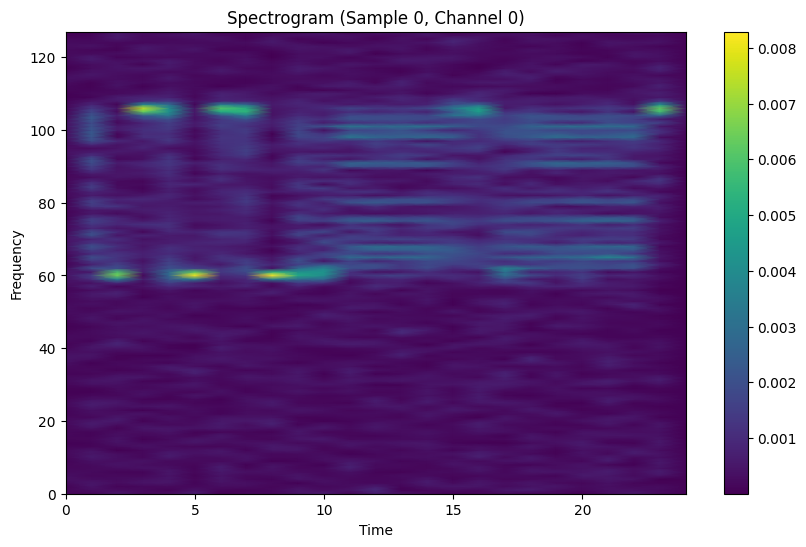

In [22]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

# Assuming data_spectrogram is already computed
# Print the shape of the computed spectrograms
print(f"Spectrogram shape: {data_spectrogram.shape}")

# Example: Display the spectrogram of the first sample, first channel
def plot_spectrogram(spectrogram, sample_idx=0, channel_idx=0):
    f, ax = plt.subplots(figsize=(10, 6))
    spect = np.abs(spectrogram[sample_idx, :, :, channel_idx])  # Magnitude of STFT
    ax.pcolormesh(spect, shading='gouraud')
    ax.set_title(f"Spectrogram (Sample {sample_idx}, Channel {channel_idx})")
    ax.set_xlabel("Time")
    ax.set_ylabel("Frequency")
    plt.colorbar(ax.pcolormesh(spect, shading='gouraud'))
    plt.show()

# Plot the spectrogram of the first sample and first channel
plot_spectrogram(data_spectrogram)


In [23]:
data_spectrogram

array([[[[1.36382461e-04, 2.01453847e-04],
         [1.54340516e-04, 6.76814753e-05],
         [5.04993160e-04, 4.08502762e-05],
         ...,
         [5.31697097e-04, 4.66224027e-04],
         [2.42179005e-04, 2.19475459e-04],
         [6.75164736e-05, 9.26511619e-05]],

        [[1.42756563e-04, 2.22645316e-04],
         [2.64446162e-04, 2.93436992e-04],
         [2.88609805e-04, 7.74116346e-05],
         ...,
         [3.34527452e-04, 3.41230040e-04],
         [2.31582981e-04, 2.98201272e-04],
         [6.68322547e-05, 8.17927084e-05]],

        [[8.71328318e-05, 1.91802702e-04],
         [4.29523978e-04, 2.71412001e-04],
         [1.22129558e-04, 1.76718505e-04],
         ...,
         [2.13648645e-04, 4.07162050e-04],
         [2.81764503e-04, 1.94823148e-04],
         [6.77812115e-05, 7.25914702e-05]],

        ...,

        [[1.72192046e-04, 1.87741724e-04],
         [1.68897982e-04, 6.82459399e-05],
         [5.30347837e-04, 1.12174804e-04],
         ...,
         [2.17557369e

In [37]:
# Check if labels match the number of samples
print(f"Shape of labels: {labels.shape}")

# Ensure labels have the correct shape (number of samples should match data_spectrogram)
if labels.shape[0] != data_spectrogram.shape[0]:
    # Fix the label shape if necessary (e.g., repeat labels or load the correct ones)
    # Assuming you have labels that match the data
    label = labels

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_spectrogram, labels, test_size=0.2, random_state=42
)

# Check the shape of the data
print(f'Shape of data_train: {data_train.shape}')
print(f'Shape of data_test: {data_test.shape}')


Shape of labels: (3372, 1)
Shape of data_train: (2697, 128, 80, 2)
Shape of data_test: (675, 128, 80, 2)


In [24]:
import numpy as np
magnitude = np.abs(data_spectrogram)  # Magnitude
phase = np.angle(data_spectrogram)    # Phase
from sklearn.preprocessing import MinMaxScaler

scaler_mag = MinMaxScaler()
magnitude_scaled = scaler_mag.fit_transform(magnitude.reshape(-1, 1)).reshape(magnitude.shape)

scaler_phase = MinMaxScaler()
phase_scaled = scaler_phase.fit_transform(phase.reshape(-1, 1)).reshape(phase.shape)
combined_features = np.concatenate((magnitude_scaled, phase_scaled), axis=-1)


from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Flatten the combined features if necessary
combined_features_flat = combined_features.reshape(combined_features.shape[0], -1)

X_train, X_test, y_train, y_test = train_test_split(combined_features_flat, labels, test_size=0.2, random_state=42)
svm = SVC(kernel='rbf', C=10, gamma='scale')
svm.fit(X_train, y_train)

# Predict and calculate accuracy
y_pred = svm.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")


/home/codespace/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy: 0.23555555555555555


In [25]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize Gradient Boosting Classifier
gb_classifier = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Train the classifier
gb_classifier.fit(X_train, y_train)

# Predict and calculate accuracy
y_pred = gb_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")


/home/codespace/.local/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy: 0.2637037037037037


In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Flatten the combined features if necessary
combined_features_flat = combined_features.reshape(combined_features.shape[0], -1)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(combined_features_flat, labels, test_size=0.2, random_state=42)

# Initialize Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)

# Train the classifier
rf_classifier.fit(X_train, y_train)

# Predict and calculate accuracy
y_pred = rf_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")


/home/codespace/.local/lib/python3.10/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Accuracy: 0.2414814814814815


In [ ]:
import numpy as np
magnitude = np.abs(data_spectrogram)  # Magnitude
phase = np.angle(data_spectrogram)    # Phase
from sklearn.preprocessing import MinMaxScaler

scaler_mag = MinMaxScaler()
magnitude_scaled = scaler_mag.fit_transform(magnitude.reshape(-1, 1)).reshape(magnitude.shape)

scaler_phase = MinMaxScaler()
phase_scaled = scaler_phase.fit_transform(phase.reshape(-1, 1)).reshape(phase.shape)
combined_features = np.concatenate((magnitude_scaled, phase_scaled), axis=-1)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout

# Reshape the data to combine frequency and channel dimensions
data_train_reshaped = data_train.reshape(data_train.shape[0], data_train.shape[1], -1)
data_test_reshaped = data_test.reshape(data_test.shape[0], data_test.shape[1], -1)

# Check the reshaped data
print(f"Reshaped data_train: {data_train_reshaped.shape}")
print(f"Reshaped data_test: {data_test_reshaped.shape}")

# Build the BiLSTM model with more units and Adam optimizer
model = Sequential()
model.add(Bidirectional(LSTM(256, return_sequences=True), input_shape=(128, 80*2)))  # Increased LSTM units
model.add(BatchNormalization())
model.add(Dropout(0.4))  # Increased dropout
model.add(Bidirectional(LSTM(128)))  # Added a layer with more LSTM units
model.add(Dropout(0.4))
model.add(Dense(128, activation='relu'))  # Increased Dense layer size
model.add(Dropout(0.4))
model.add(Dense(len(np.unique(labels)), activation='softmax'))

# Compile with Adam optimizer
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Adjust early stopping and learning rate reduction
early_stopping = EarlyStopping(monitor='val_loss', patience=20)  # Increased patience
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)  # Adjusted factor for learning rate decay

# Train the model with increased epochs
history = model.fit(data_train_reshaped, label_train, epochs=5, batch_size=32, validation_split=0.2, callbacks=[early_stopping, reduce_lr])

# Feature extraction and SVM classification remains the same
model_feature_extractor = Sequential(model.layers[:-2])
features_train = model_feature_extractor.predict(data_train_reshaped)
features_test = model_feature_extractor.predict(data_test_reshaped)

# SVM classification
clf = SVC(kernel='rbf', C=1.0, gamma='auto', random_state=42)
clf.fit(features_train, label_train)

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')
# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Plot the loss function
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [41]:
from keras.models import Sequential
from keras.layers import Bidirectional, LSTM, BatchNormalization, Dropout, Dense
from keras.optimizers import RMSprop
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

data_train_reshaped = data_train.reshape(data_train.shape[0], data_train.shape[1], -1)
data_test_reshaped = data_test.reshape(data_test.shape[0], data_test.shape[1], -1)

# Check the reshaped data
print(f"Reshaped data_train: {data_train_reshaped.shape}")
print(f"Reshaped data_test: {data_test_reshaped.shape}")

# Example of data normalization
scaler = StandardScaler()
data_train_reshaped = scaler.fit_transform(data_train_reshaped.reshape(-1, data_train_reshaped.shape[-1])).reshape(data_train_reshaped.shape)
data_test_reshaped = scaler.transform(data_test_reshaped.reshape(-1, data_test_reshaped.shape[-1])).reshape(data_test_reshaped.shape)

# Improved model architecture
model = Sequential()
model.add(Bidirectional(LSTM(512, return_sequences=True), input_shape=(128, 160)))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Bidirectional(LSTM(256, return_sequences=True)))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Bidirectional(LSTM(128)))
model.add(Dropout(0.5))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(len(np.unique(labels)), activation='softmax'))

# Compile with RMSprop optimizer
model.compile(optimizer=RMSprop(learning_rate=0.0005), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Adjust early stopping and learning rate reduction
early_stopping = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, verbose=1)

# Train the model with increased epochs
history = model.fit(data_train_reshaped, label_train, epochs=20, batch_size=32, validation_split=0.2, callbacks=[early_stopping, reduce_lr])

# Feature extraction and SVM classification remains the same
model_feature_extractor = Sequential(model.layers[:-2])
features_train = model_feature_extractor.predict(data_train_reshaped)
features_test = model_feature_extractor.predict(data_test_reshaped)

# SVM classification
clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
clf.fit(features_train, label_train)

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')
# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Plot the loss function
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


Reshaped data_train: (2697, 128, 160)
Reshaped data_test: (675, 128, 160)


/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20


68/68 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.2423 - loss: 1.5190 - val_accuracy: 0.2407 - val_loss: 1.3976 - learning_rate: 5.0000e-04
Epoch 2/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.2570 - loss: 1.4433 - val_accuracy: 0.2574 - val_loss: 1.3956 - learning_rate: 5.0000e-04
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.2607 - loss: 1.4372 - val_accuracy: 0.2556 - val_loss: 1.3850 - learning_rate: 5.0000e-04
Epoch 4/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 199s 2s/step - accuracy: 0.2421 - loss: 1.4121 - val_accuracy: 0.2407 - val_loss: 1.3880 - learning_rate: 5.0000e-04
Epoch 5/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.2598 - loss: 1.3987 - val_accuracy: 0.2741 - val_loss: 1.3869 - learning_rate: 5.0000e-04
Epoch 6/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.2234 - loss: 1.4174 - val_accuracy: 0.2444 - val_loss: 1.3859 - learning_rate: 5.0000e-04
Epoch 7/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.2569 - loss: 1.3

KeyboardInterrupt: 

In [39]:
# Reshape the data to combine frequency and channel dimensions
data_train_reshaped = data_train.reshape(data_train.shape[0], data_train.shape[1], -1)
data_test_reshaped = data_test.reshape(data_test.shape[0], data_test.shape[1], -1)

# Check the reshaped data
print(f"Reshaped data_train: {data_train_reshaped.shape}")
print(f"Reshaped data_test: {data_test_reshaped.shape}")

# Build the BiLSTM model with more units and Adam optimizer
model = Sequential()
model.add(Bidirectional(LSTM(256, return_sequences=True), input_shape=(128, 80*2)))  # Increased LSTM units
model.add(BatchNormalization())
model.add(Dropout(0.4))  # Increased dropout
model.add(Bidirectional(LSTM(128)))  # Added a layer with more LSTM units
model.add(Dropout(0.4))
model.add(Dense(128, activation='relu'))  # Increased Dense layer size
model.add(Dropout(0.4))
model.add(Dense(len(np.unique(labels)), activation='softmax'))

# Compile with Adam optimizer
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Adjust early stopping and learning rate reduction
early_stopping = EarlyStopping(monitor='val_loss', patience=20)  # Increased patience
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)  # Adjusted factor for learning rate decay

# Train the model with increased epochs
history = model.fit(data_train_reshaped, label_train, epochs=5, batch_size=32, validation_split=0.2, callbacks=[early_stopping, reduce_lr])

# Feature extraction and SVM classification remains the same
model_feature_extractor = Sequential(model.layers[:-2])
features_train = model_feature_extractor.predict(data_train_reshaped)
features_test = model_feature_extractor.predict(data_test_reshaped)

# SVM classification
clf = SVC(kernel='rbf', C=1.0, gamma='auto', random_state=42)
clf.fit(features_train, label_train)

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')
# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Plot the loss function
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


Reshaped data_train: (2697, 128, 160)
Reshaped data_test: (675, 128, 160)


/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5


2024-09-06 09:41:45.730463: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 176701440 exceeds 10% of free system memory.


68/68 ━━━━━━━━━━━━━━━━━━━━ 42s 540ms/step - accuracy: 0.2422 - loss: 1.5114 - val_accuracy: 0.2574 - val_loss: 1.4041 - learning_rate: 0.0010
Epoch 2/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 40s 529ms/step - accuracy: 0.2761 - loss: 1.4079 - val_accuracy: 0.2500 - val_loss: 1.3843 - learning_rate: 0.0010
Epoch 3/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 36s 533ms/step - accuracy: 0.2496 - loss: 1.4030 - val_accuracy: 0.2741 - val_loss: 1.3868 - learning_rate: 0.0010
Epoch 4/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 36s 529ms/step - accuracy: 0.2748 - loss: 1.3915 - val_accuracy: 0.2278 - val_loss: 1.3872 - learning_rate: 0.0010
Epoch 5/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 36s 529ms/step - accuracy: 0.2652 - loss: 1.3933 - val_accuracy: 0.2407 - val_loss: 1.3869 - learning_rate: 0.0010


...

2024-09-06 09:45:07.059151: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 55296000 exceeds 10% of free system memory.


22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step


/home/codespace/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy: 22.37%
Precision: 5.00%
Recall: 22.37%
F1 Score: 8.18%


/home/codespace/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Reshaped data_train: (2697, 65, 316)
Reshaped data_test: (675, 65, 316)


/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2024-09-05 22:00:40.403172: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 177219120 exceeds 10% of free system memory.


Epoch 1/20


68/68 ━━━━━━━━━━━━━━━━━━━━ 11s 117ms/step - accuracy: 0.2600 - loss: 1.4477 - val_accuracy: 0.2574 - val_loss: 1.3865 - learning_rate: 0.0010
Epoch 2/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.2518 - loss: 1.4058 - val_accuracy: 0.2259 - val_loss: 1.3906 - learning_rate: 0.0010
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - accuracy: 0.2497 - loss: 1.4005 - val_accuracy: 0.2296 - val_loss: 1.3918 - learning_rate: 0.0010
Epoch 4/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.2449 - loss: 1.3909 - val_accuracy: 0.2519 - val_loss: 1.3881 - learning_rate: 0.0010
Epoch 5/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - accuracy: 0.2601 - loss: 1.3921 - val_accuracy: 0.2407 - val_loss: 1.3876 - learning_rate: 0.0010
Epoch 6/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.2431 - loss: 1.3942
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - accuracy: 0.2430 - loss: 1.3942 - val_accu

2024-09-05 22:03:33.962540: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 221585520 exceeds 10% of free system memory.


85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


/home/codespace/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy: 22.37%
Precision: 5.00%
Recall: 22.37%
F1 Score: 8.18%


/home/codespace/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


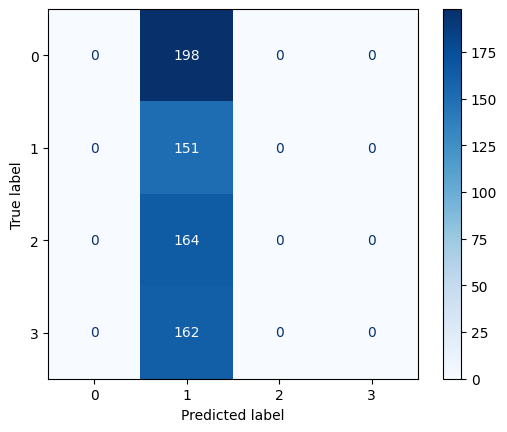

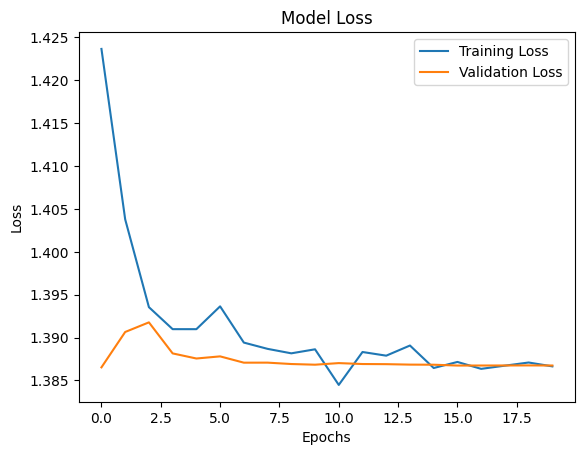

In [88]:
# Reshape the data to combine frequency and channel dimensions
data_train_reshaped = data_train.reshape(data_train.shape[0], data_train.shape[1], -1)
data_test_reshaped = data_test.reshape(data_test.shape[0], data_test.shape[1], -1)

# Check the reshaped data
print(f"Reshaped data_train: {data_train_reshaped.shape}")
print(f"Reshaped data_test: {data_test_reshaped.shape}")


# Build the BiLSTM model
model = Sequential()
model.add(Bidirectional(LSTM(128, return_sequences=True), input_shape=(65, 158*2)))  # Adjusted input shape
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Bidirectional(LSTM(64)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(len(np.unique(label)), activation='softmax'))  # Adjusted for multiclass classification

# Compile the model
model.compile(optimizer=RMSprop(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model using reshaped data
early_stopping = EarlyStopping(monitor='val_loss', patience=100)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, verbose=1)
history = model.fit(data_train_reshaped, label_train, epochs=20, batch_size=32, validation_split=0.2, callbacks=[early_stopping, reduce_lr])  # Use reshaped data

# Extract features from the BiLSTM model
model_feature_extractor = Sequential(model.layers[:-2])  # Remove the last two layers to get features
features_train = model_feature_extractor.predict(data_train_reshaped)  # Use reshaped data
features_test = model_feature_extractor.predict(data_test_reshaped)  # Use reshaped data

# Save the BiLSTM feature extractor model
model_feature_extractor.save('1_extractor_bilstm.h5')

# Classification with SVM
clf = SVC(kernel='rbf', C=1.0, gamma='auto', random_state=42)
clf.fit(features_train, label_train)

# Save the SVM model
joblib.dump(clf, '1_model_svm.pkl')

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Plot the loss function
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [58]:
# Reshape the data to combine frequency and channel dimensions
data_train_reshaped = data_train.reshape(data_train.shape[0], data_train.shape[1], -1)
data_test_reshaped = data_test.reshape(data_test.shape[0], data_test.shape[1], -1)

# Check the reshaped data
print(f"Reshaped data_train: {data_train_reshaped.shape}")
print(f"Reshaped data_test: {data_test_reshaped.shape}")


# Build the BiLSTM model
model = Sequential()
model.add(Bidirectional(LSTM(128, return_sequences=True), input_shape=(65,48*2)))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Bidirectional(LSTM(64)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(len(np.unique(label)), activation='softmax'))  # Adjusted for multiclass classification

# Compile the model
model.compile(optimizer=RMSprop(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
#early_stopping = EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)
early_stopping = EarlyStopping(monitor='val_loss', patience=10)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, verbose=1)
history = model.fit(data_train, label_train, epochs=5, batch_size=32, validation_split=0.2, callbacks=[early_stopping,reduce_lr])

# Extract features from the BiLSTM model
model_feature_extractor = Sequential(model.layers[:-2])  # Remove the last two layers to get features
features_train = model_feature_extractor.predict(data_train)
features_test = model_feature_extractor.predict(data_test)

# Save the BiLSTM feature extractor model
model_feature_extractor.save('1_extractor_bilstm.h5')

# Classification with SVM
clf = SVC(kernel='rbf', C=1.0, gamma='auto', random_state=42)
clf.fit(features_train, label_train)

# Save the SVM model
joblib.dump(clf, '1_model_svm.pkl')

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Plot the loss function
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Reshaped data_train: (2697, 65, 96)
Reshaped data_test: (675, 65, 96)
Epoch 1/5


2024-09-05 21:36:50.947576: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 53838720 exceeds 10% of free system memory.


ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(None, 65, 48, 2), dtype=float32). Expected shape (None, 65, 96), but input has incompatible shape (None, 65, 48, 2)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 65, 48, 2), dtype=float32)
  • training=True
  • mask=None

In [ ]:
# Normalize the spectrograms
scaler = StandardScaler()
data_spectrogram_scaled = scaler.fit_transform(data_spectrogram.reshape(-1, data_spectrogram.shape[-1])).reshape(data_spectrogram.shape)

# Reshape data for BiLSTM input (samples, timesteps, features)
n_samples, n_freq_bins, n_time_bins, n_channels = data_spectrogram_scaled.shape
data_scaled = data_spectrogram_scaled.reshape(n_samples, n_freq_bins, n_time_bins * n_channels)

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_scaled, label, test_size=0.2, random_state=42
)

# Check the shape of the data
print(f'Shape of data_train: {data_train.shape}')
print(f'Shape of data_test: {data_test.shape}')

# Build the BiLSTM model
model = Sequential()
model.add(Bidirectional(LSTM(128, return_sequences=True), input_shape=(n_freq_bins, n_time_bins * n_channels)))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Bidirectional(LSTM(64)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(len(np.unique(label)), activation='softmax'))  # Adjusted for multiclass classification

# Compile the model
model.compile(optimizer=RMSprop(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
#early_stopping = EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)
early_stopping = EarlyStopping(monitor='val_loss', patience=10)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, verbose=1)
history = model.fit(data_train, label_train, epochs=5, batch_size=32, validation_split=0.2, callbacks=[early_stopping,reduce_lr])

# Extract features from the BiLSTM model
model_feature_extractor = Sequential(model.layers[:-2])  # Remove the last two layers to get features
features_train = model_feature_extractor.predict(data_train)
features_test = model_feature_extractor.predict(data_test)

# Save the BiLSTM feature extractor model
model_feature_extractor.save('1_extractor_bilstm.h5')

# Classification with SVM
clf = SVC(kernel='rbf', C=1.0, gamma='auto', random_state=42)
clf.fit(features_train, label_train)

# Save the SVM model
joblib.dump(clf, '1_model_svm.pkl')

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Plot the loss function
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [24]:
import numpy as np
import joblib
import matplotlib.pyplot as plt
from scipy.signal import stft
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from xgboost import XGBClassifier

# Assuming X_train_pca has shape (3372, 1985)
n_samples = X_train_pca.shape[0]
n_timesteps = 991   # Define based on the number of channels
n_channels = 2      # Define based on your data

# Truncate or adjust if necessary to ensure compatibility
if n_timesteps * n_channels != 1985:
    X_train_pca = X_train_pca[:, :n_timesteps * n_channels]

# Reshape to (samples, timesteps, channels)
data_real = X_train_pca.reshape(n_samples, n_timesteps, n_channels)

# Function to compute channel-independent spectrograms using STFT
def compute_spectrogram(data, nperseg=128, noverlap=64):
    spectrograms = []
    for sample in data:
        sample_spectrograms = []
        for channel in range(sample.shape[-1]):  # Iterate over channels
            f, t, Zxx = stft(sample[:, channel], nperseg=nperseg, noverlap=noverlap)
            sample_spectrograms.append(np.abs(Zxx))
        # Stack all channel spectrograms along the last axis
        spectrograms.append(np.stack(sample_spectrograms, axis=-1))
    return np.array(spectrograms)

# Compute spectrograms
data_spectrogram = compute_spectrogram(data_real)




ValueError: cannot reshape array of size 5162532 into shape (3372,991,2)

In [ ]:
# Normalize the spectrograms
scaler = StandardScaler()
data_spectrogram_scaled = scaler.fit_transform(data_spectrogram.reshape(-1, data_spectrogram.shape[-1])).reshape(data_spectrogram.shape)

# Reshape data for BiLSTM input (samples, timesteps, features)
n_samples, n_freq_bins, n_time_bins, n_channels = data_spectrogram_scaled.shape
data_scaled = data_spectrogram_scaled.reshape(n_samples, n_freq_bins, n_time_bins * n_channels)

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_scaled, label, test_size=0.2, random_state=42
)

# Check the shape of the data
print(f'Shape of data_train: {data_train.shape}')
print(f'Shape of data_test: {data_test.shape}')

# Build the BiLSTM model
model = Sequential()
model.add(Bidirectional(LSTM(128, return_sequences=True), input_shape=(n_freq_bins, n_time_bins * n_channels)))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Bidirectional(LSTM(64)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(len(np.unique(label)), activation='softmax'))  # Adjusted for multiclass classification

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(data_train, label_train, epochs=100, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

# Extract features from the BiLSTM model
model_feature_extractor = Sequential(model.layers[:-2])  # Remove the last two layers to get features
features_train = model_feature_extractor.predict(data_train)
features_test = model_feature_extractor.predict(data_test)

# Save the BiLSTM feature extractor model
model_feature_extractor.save('1_extractor_bilstm.h5')

# Classification with XGBoost
clf = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
clf.fit(features_train, label_train)

# Save the XGBoost model
joblib.dump(clf, '1_model_bilstm.pkl')

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Plot the loss function
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Shape of data_train: (2697, 65, 34)
Shape of data_test: (675, 65, 34)
Epoch 1/100


/usr/local/python/3.10.13/lib/python3.10/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.2716 - loss: 1.4369 - val_accuracy: 0.2630 - val_loss: 1.3853
Epoch 2/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - accuracy: 0.2761 - loss: 1.3938 - val_accuracy: 0.2463 - val_loss: 1.3923
Epoch 3/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.2609 - loss: 1.3953 - val_accuracy: 0.2611 - val_loss: 1.3904
Epoch 4/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - accuracy: 0.2773 - loss: 1.3893 - val_accuracy: 0.2593 - val_loss: 1.3917
Epoch 5/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - accuracy: 0.2529 - loss: 1.3899 - val_accuracy: 0.2556 - val_loss: 1.3881
Epoch 6/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - accuracy: 0.2742 - loss: 1.3881 - val_accuracy: 0.2593 - val_loss: 1.3878
Epoch 7/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - accuracy: 0.2891 - loss: 1.3796 - val_accuracy: 0.2389 - val_loss: 1.3901
Epoch 8/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - accuracy: 0.2883 - loss: 1.3742 - val_accuracy: 0.2426 - va

Accuracy: 21.93%
Precision: 22.61%
Recall: 21.93%
F1 Score: 22.12%


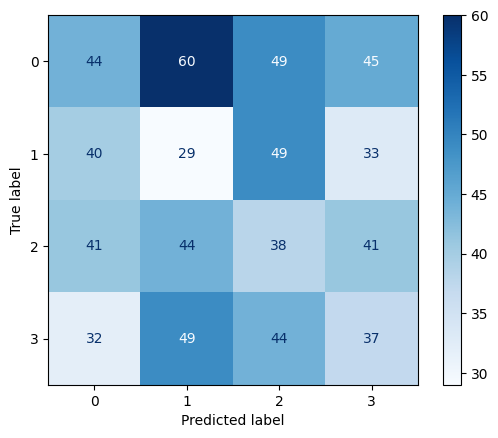

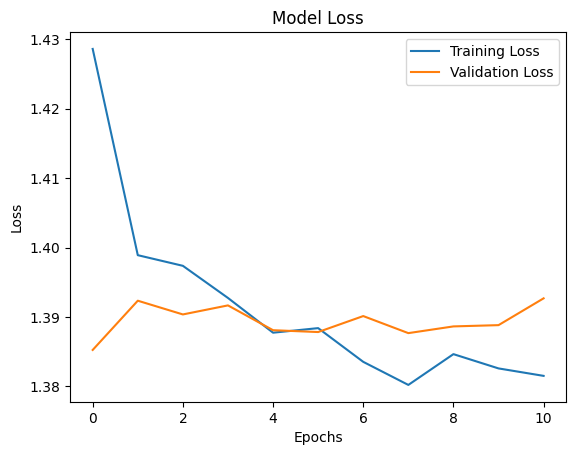

In [51]:
import numpy as np
import joblib
import matplotlib.pyplot as plt
from scipy.signal import stft
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from xgboost import XGBClassifier

# Assuming X_train_pca has shape (3372, 1985)
n_samples = X_train_pca.shape[0]
n_timesteps = 992   # Define based on the number of channels
n_channels = 2      # Define based on your data

# Truncate or adjust if necessary to ensure compatibility
if n_timesteps * n_channels != 1985:
    X_train_pca = X_train_pca[:, :n_timesteps * n_channels]

# Reshape to (samples, timesteps, channels)
data_real = X_train_pca.reshape(n_samples, n_timesteps, n_channels)

# Function to compute channel-independent spectrograms using STFT
def compute_spectrogram(data, nperseg=128, noverlap=64):
    spectrograms = []
    for sample in data:
        sample_spectrograms = []
        for channel in range(sample.shape[-1]):  # Iterate over channels
            f, t, Zxx = stft(sample[:, channel], nperseg=nperseg, noverlap=noverlap)
            sample_spectrograms.append(np.abs(Zxx))
        # Stack all channel spectrograms along the last axis
        spectrograms.append(np.stack(sample_spectrograms, axis=-1))
    return np.array(spectrograms)

# Compute spectrograms
data_spectrogram = compute_spectrogram(data_real)

# Normalize the spectrograms
scaler = StandardScaler()
data_spectrogram_scaled = scaler.fit_transform(data_spectrogram.reshape(-1, data_spectrogram.shape[-1])).reshape(data_spectrogram.shape)

# Reshape data for BiLSTM input (samples, timesteps, features)
n_samples, n_freq_bins, n_time_bins, n_channels = data_spectrogram_scaled.shape
data_scaled = data_spectrogram_scaled.reshape(n_samples, n_freq_bins, n_time_bins * n_channels)

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_scaled, label, test_size=0.2, random_state=42
)

# Check the shape of the data
print(f'Shape of data_train: {data_train.shape}')
print(f'Shape of data_test: {data_test.shape}')

# Build the BiLSTM model
model = Sequential()
model.add(Bidirectional(LSTM(128, return_sequences=True), input_shape=(n_freq_bins, n_time_bins * n_channels)))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Bidirectional(LSTM(64)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(len(np.unique(label)), activation='softmax'))  # Adjusted for multiclass classification

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(data_train, label_train, epochs=100, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

# Extract features from the BiLSTM model
model_feature_extractor = Sequential(model.layers[:-2])  # Remove the last two layers to get features
features_train = model_feature_extractor.predict(data_train)
features_test = model_feature_extractor.predict(data_test)

# Save the BiLSTM feature extractor model
model_feature_extractor.save('1_extractor_bilstm.h5')

# Classification with XGBoost
clf = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
clf.fit(features_train, label_train)

# Save the XGBoost model
joblib.dump(clf, '1_model_bilstm.pkl')

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Plot the loss function
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


Shape of data_train: (2697, 65, 17, 2)
Shape of data_test: (675, 65, 17, 2)
Epoch 1/100


/usr/local/python/3.10.13/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.2632 - loss: 1.9452 - val_accuracy: 0.2167 - val_loss: 1.5172
Epoch 2/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.2649 - loss: 1.4203 - val_accuracy: 0.2278 - val_loss: 2.1610
Epoch 3/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.2678 - loss: 1.3913 - val_accuracy: 0.2278 - val_loss: 2.3343
Epoch 4/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.2607 - loss: 1.3951 - val_accuracy: 0.2278 - val_loss: 1.9089
Epoch 5/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.2579 - loss: 1.3873 - val_accuracy: 0.2370 - val_loss: 1.5249
Epoch 6/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.2500 - loss: 1.3867 - val_accuracy: 0.2685 - val_loss: 1.3972
Epoch 7/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.2404 - loss: 1.3879 - val_accuracy: 0.2537 - val_loss: 1.3885
Epoch 8/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.2573 - loss: 1.3872 - val_accuracy: 0.2574 - val_l

Accuracy: 27.11%
Precision: 29.53%
Recall: 27.11%
F1 Score: 25.65%


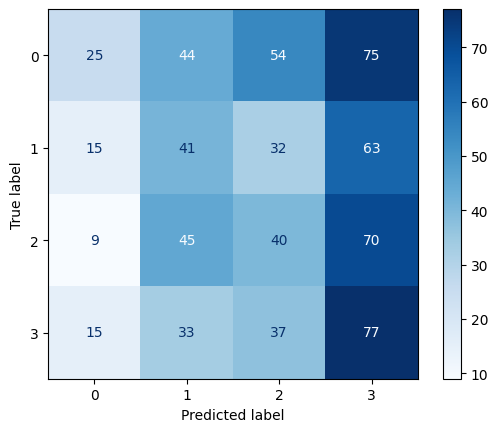

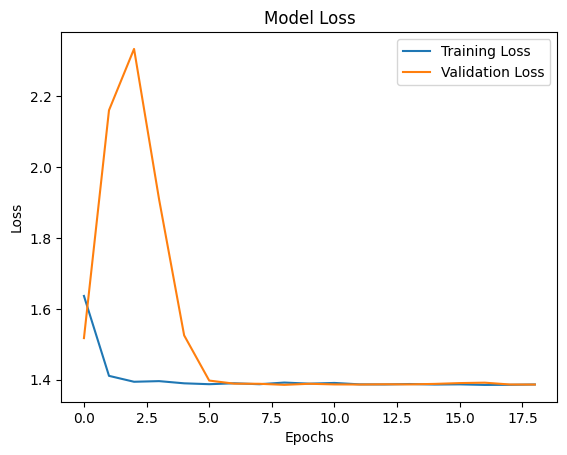

In [49]:
import numpy as np
import joblib
import matplotlib.pyplot as plt
from scipy.signal import stft
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from xgboost import XGBClassifier

# Assuming X_train_pca has shape (3372, 1985)
n_samples = X_train_pca.shape[0]
n_timesteps = 992   # Define based on the number of channels
n_channels = 2     # Define based on your data

# Truncate or adjust if necessary to ensure compatibility
if n_timesteps * n_channels != 1985:
    X_train_pca = X_train_pca[:, :n_timesteps * n_channels]

# Reshape to (samples, timesteps, channels)
data_real = X_train_pca.reshape(n_samples, n_timesteps, n_channels)

# Function to compute channel-independent spectrograms using STFT
def compute_spectrogram(data, nperseg=128, noverlap=64):
    spectrograms = []
    for sample in data:
        sample_spectrograms = []
        for channel in range(sample.shape[-1]):  # Iterate over channels
            f, t, Zxx = stft(sample[:, channel], nperseg=nperseg, noverlap=noverlap)
            sample_spectrograms.append(np.abs(Zxx))
        # Stack all channel spectrograms along the last axis
        spectrograms.append(np.stack(sample_spectrograms, axis=-1))
    return np.array(spectrograms)

# Compute spectrograms
data_spectrogram = compute_spectrogram(data_real)

# Normalize the spectrograms
scaler = StandardScaler()
data_spectrogram_scaled = scaler.fit_transform(data_spectrogram.reshape(-1, data_spectrogram.shape[-1])).reshape(data_spectrogram.shape)

# Reshape data for CNN input (samples, height, width, channels)
n_samples, n_freq_bins, n_time_bins, n_channels = data_spectrogram_scaled.shape
data_scaled = data_spectrogram_scaled.reshape(n_samples, n_freq_bins, n_time_bins, n_channels)

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_scaled, label, test_size=0.2, random_state=42
)

# Check the shape of the data
print(f'Shape of data_train: {data_train.shape}')
print(f'Shape of data_test: {data_test.shape}')

# Build the CNN model
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(n_freq_bins, n_time_bins, n_channels)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.3))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(len(np.unique(label)), activation='softmax'))  # Adjusted for multiclass classification

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(data_train, label_train, epochs=100, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

# Extract features from the CNN model
model_feature_extractor = Sequential(model.layers[:-2])  # Remove the last two layers to get features
features_train = model_feature_extractor.predict(data_train)
features_test = model_feature_extractor.predict(data_test)

# Save the CNN feature extractor model
model_feature_extractor.save('1_extractor.h5')

# Classification with XGBoost
clf = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
clf.fit(features_train, label_train)

# Save the XGBoost model
joblib.dump(clf, '1_model.pkl')

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Plot the loss function
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [81]:
%pip install xgboost



[notice] A new release of pip is available: 24.0 -> 24.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
ChannelIndSpectrogram

In [62]:
#number_of_legitmate = samples_from_each_device*2
# legitmate_data = data[0:number_of_legitmate]
# illegitmate_data = data[number_of_legitmate:]
#legitmate_labels = labels[0:number_of_legitmate]
#illegitmate_labels = labels[number_of_legitmate:]

# legitmate = 0
# illegitmate = 1

#binary_labels = np.where(labels <=1, 0, 1)

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Step 1: Handle Complex Numbers (Separating real and imaginary parts)
def separate_complex_features(data):
    real_part = np.real(data)
    imag_part = np.imag(data)
    return np.hstack((real_part, imag_part))

# Step 2: Preprocess the data using the preprocessing method
training_data = []

def create_training_data(Input_list, Desired_target_index):
    for i in range(len(Input_list)):  
        # Separating real and imaginary parts and appending to training_data
        processed_features = separate_complex_features(Input_list[i])
        training_data.append([processed_features, Desired_target_index[i]])  

create_training_data(data, labels)
print("The length of training data list after adding sine data: ", len(training_data))

# Step 3: Shuffle the data
import random
random.shuffle(training_data)

# Step 4: Separate features and labels
x_train = []
y_train = []

for features, label in training_data:
    x_train.append(features)
    y_train.append(label)

x_train = np.array(x_train)
y_train = np.array(y_train, dtype=np.uint8)

# Step 5: Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)

# Optional: Split the data into training and testing sets
#X_train, X_test, y_train, y_test = train_test_split(X_train_scaled, y_train, test_size=0.2, random_state=42)

# Now you can use X_train, y_train for training your model
# And X_test, y_test for testing its performance


In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# Step 1: Separate real and imaginary parts
def separate_complex_features(data):
    real_part = np.real(data)
    imag_part = np.imag(data)
    return np.hstack((real_part, imag_part))

# Step 2: Preprocess the data
training_data = []

def create_training_data(Input_list, Desired_target_index):
    for i in range(len(Input_list)):  
        processed_features = separate_complex_features(Input_list[i])
        training_data.append([processed_features, Desired_target_index[i]])  

create_training_data(data, labels)
print("Length of training data list:", len(training_data))

# Step 3: Shuffle the data
import random
random.shuffle(training_data)

# Step 4: Separate features and labels
x_train = []
y_train = []

for features, label in training_data:
    x_train.append(features)
    y_train.append(label)

x_train = np.array(x_train)
y_train = np.array(y_train, dtype=np.uint8)

# Step 5: Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)

# Step 6 (Optional): Apply PCA for dimensionality reduction
#pca = PCA(n_components=0.95)  # Keep 95% of variance
#X_train_pca = pca.fit_transform(X_train_scaled)

# Step 7: Split the data into training and testing sets
#X_train, X_test, y_train, y_test = train_test_split(X_train_pca, y_train, test_size=0.2, random_state=42)

# The preprocessed data is now ready for training a model
